## Build Dataset — 3 Class Problem

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

np.random.seed(42)
n = 1200

df = pd.DataFrame({
    'study_hours'   : np.random.normal(6, 2, n).clip(0, 12),
    'sleep_hours'   : np.random.normal(7, 1.5, n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'    : np.random.normal(65, 15, n).clip(0, 100),
    'stress_level'  : np.random.randint(1, 10, n).astype(float),
    'exercise_days' : np.random.randint(0, 7, n).astype(float),
})

# Create 3 class target — Grade A, B, C
score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n)
)

# Split into 3 grades using percentiles
df['grade'] = pd.qcut(
    score,
    q     = 3,
    labels= [0, 1, 2]   # 0=C, 1=B, 2=A
).astype(int)

grade_names = {0: 'Grade C', 1: 'Grade B', 2: 'Grade A'}
print("Grade distribution:")
print(df['grade'].value_counts().sort_index())

X = df.drop('grade', axis=1)
y = df['grade']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Grade distribution:
grade
0    400
1    400
2    400
Name: count, dtype: int64


## Train Softmax Model

In [3]:
softmax = LogisticRegression(
    solver       = 'lbfgs',
    # ↑ lbfgs supports multinomial directly
    #   also works: 'saga', 'newton-cg'

    C            = 1.0,
    max_iter     = 1000,
    random_state = 42
)

softmax.fit(X_train_scaled, y_train)

y_pred      = softmax.predict(X_test_scaled)
y_pred_prob = softmax.predict_proba(X_test_scaled)
# ↑ shape (n_samples, 3) → probability for each grade

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Grade C', 'Grade B', 'Grade A']))

Accuracy: 0.7666666666666667

Classification Report:
              precision    recall  f1-score   support

     Grade C       0.88      0.85      0.87        81
     Grade B       0.69      0.62      0.65        84
     Grade A       0.72      0.84      0.78        75

    accuracy                           0.77       240
   macro avg       0.77      0.77      0.77       240
weighted avg       0.77      0.77      0.76       240



## Inspect Weights Per Class

Weights per class:
         study_hours  sleep_hours  attendance_pct  prev_score  stress_level  \
Grade C       -2.093       -0.588          -1.364      -1.514        -0.027   
Grade B       -0.110        0.062           0.036      -0.010         0.016   
Grade A        2.204        0.526           1.329       1.523         0.011   

         exercise_days  
Grade C         -0.067  
Grade B         -0.002  
Grade A          0.069  


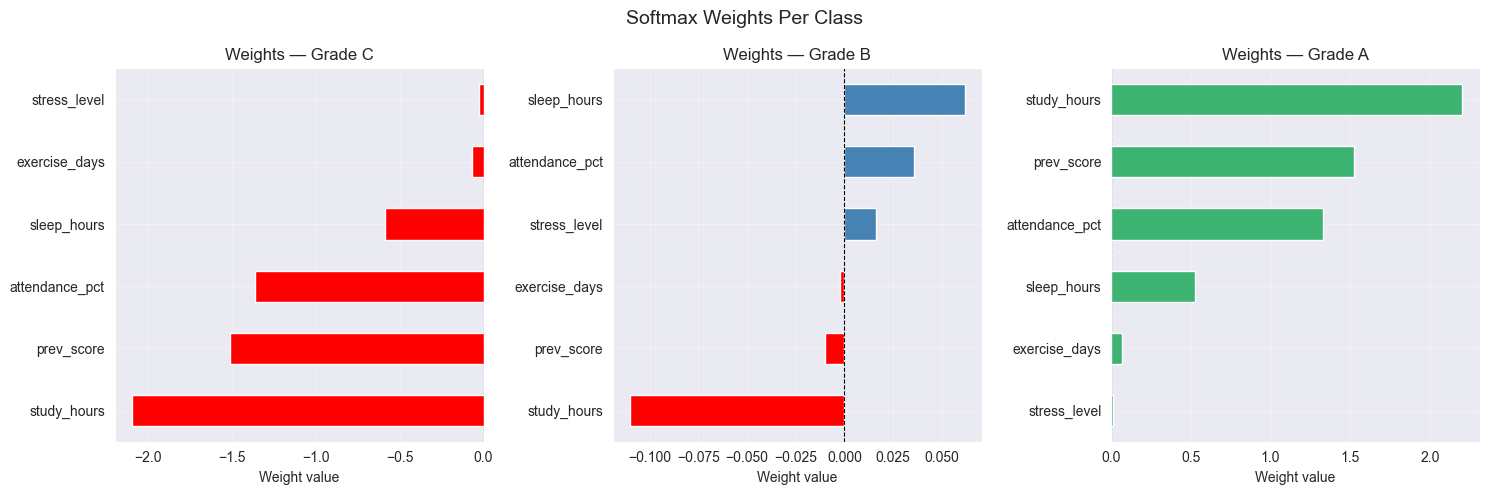

In [4]:
# coef_ shape = (n_classes, n_features) for multinomial
# one weight vector per class

weights_df = pd.DataFrame(
    softmax.coef_,
    columns = feature_names,
    index   = ['Grade C', 'Grade B', 'Grade A']
)

print("Weights per class:")
print(weights_df.round(3))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_list = ['coral', 'steelblue', 'mediumseagreen']

for ax, grade, color in zip(axes, ['Grade C', 'Grade B', 'Grade A'],
                             colors_list):
    w = weights_df.loc[grade].sort_values()
    bar_colors = ['red' if v < 0 else color for v in w]
    w.plot(kind='barh', ax=ax, color=bar_colors)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f"Weights — {grade}")
    ax.set_xlabel("Weight value")
    ax.grid(True, alpha=0.3)

plt.suptitle("Softmax Weights Per Class", fontsize=14)
plt.tight_layout()
plt.show()

# Positive weight for a class → feature pushes toward that class
# Negative weight for a class → feature pushes away from that class

## Predict One Student

In [5]:
# New student
student = pd.DataFrame({
    'study_hours'   : [8.0],
    'sleep_hours'   : [7.5],
    'attendance_pct': [90.0],
    'prev_score'    : [78.0],
    'stress_level'  : [3.0],
    'exercise_days' : [4.0]
})

student_scaled = scaler.transform(student)

probs      = softmax.predict_proba(student_scaled)[0]
prediction = softmax.predict(student_scaled)[0]

print("Predicted Probabilities:")
for grade_id, prob in enumerate(probs):
    marker = " ← predicted" if grade_id == prediction else ""
    print(f"  {grade_names[grade_id]}: {prob:.3f} ({prob*100:.1f}%){marker}")

# Predicted Probabilities:
#   Grade C: 0.041  (4.1%)
#   Grade B: 0.312  (31.2%)
#   Grade A: 0.647  (64.7%) ← predicted

Predicted Probabilities:
  Grade C: 0.000 (0.0%)
  Grade B: 0.018 (1.8%)
  Grade A: 0.982 (98.2%) ← predicted


## Confusion Matrix

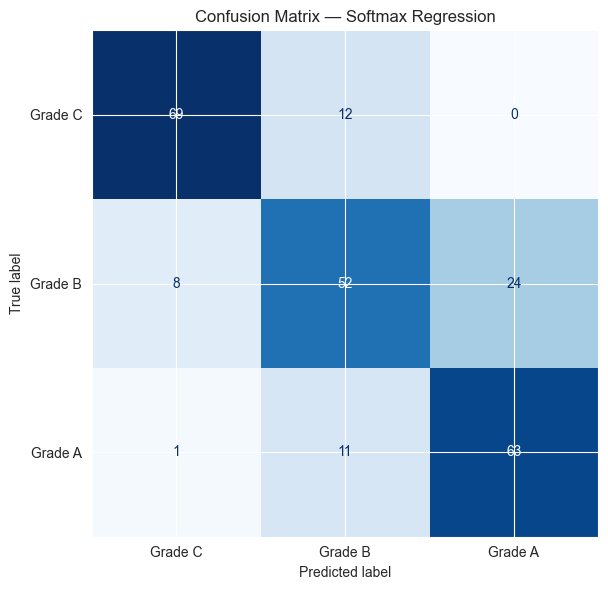

In [6]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
           cm,
           display_labels=['Grade C', 'Grade B', 'Grade A']
       )

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Confusion Matrix — Softmax Regression")
plt.tight_layout()
plt.show()

# Diagonal = correct predictions
# Off-diagonal = misclassifications
# Most errors should be in adjacent grades (C→B, not C→A)